# Chapter 5: Area

**Source span.** Hartshorne, *Geometry: Euclid and Beyond*, Chapter 5, printed pp. 195-240 / PDF pp. 207-252, Sections 22-27.

**Guiding question.** When should two geometric figures count as having the same size? Chapter 5 builds four increasingly sharp answers: equal content, equality under a numerical area function, equivalence by dissection, and equality of volume. The surprise is that the planar answers line up in an Archimedean Euclidean plane, while the three-dimensional answer splits: equal volume does not force a scissors dissection.

**Chapter goal.** Turn the chapter's synthetic claims into inspectable invariants. A learner should be able to point to a finite decomposition, an additive area ledger, an exhaustion gap, or a Dehn-invariant calculation and say exactly what is preserved.

## Computational Translation Guide

| Book language | Notebook model |
| --- | --- |
| rectilineal figure | a polygon or finite nonoverlapping union of triangles |
| equal content | stable equality after adding/removing congruent auxiliary pieces |
| measure of area function `alpha` | a positive, congruence-invariant, finitely additive map into an ordered group |
| de Zolt axiom | strict monotonicity: a proper subfigure has smaller area |
| equidecomposable/dissection equivalent | two finite decompositions matched by rigid motions piece-by-piece |
| Archimedes' axiom in dissection | repeated doubling/halving eventually reaches the needed size range |
| exhaustion | inner and outer approximations whose area gap can be made arbitrarily small |
| Dehn invariant | a 3D edge-length/dihedral-angle ledger that survives dissection |

## Route

1. Build the area function from triangle area and finite additivity.
2. Visualize dissection as a constructive strengthening of area equality.
3. Approximate circular area with inscribed/circumscribed polygons and a quadrature curve.
4. Compare volume by exhaustion with Dehn's obstruction to 3D scissors equivalence.
5. Run an applied lab that tests when a one-cut parallelogram-to-rectangle dissection works.
6. End with `final_sanity` checks for identities, artifacts, and the absence of the generic visual builder.


In [1]:
from pathlib import Path
import sys
import math
import json

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon, Circle

import networkx as nx
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp

try:
    import trimesh
except Exception:
    trimesh = None


def find_book_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
            return candidate
        nested = candidate / "Euclid-and-Beyond"
        if (nested / "00-book-index.ipynb").exists() and (nested / "utils").exists():
            return nested
    raise FileNotFoundError("Could not locate Euclid-and-Beyond book root")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib, save_plotly_html

UNIT = "chapter-05"
CHAPTER_ROOT = BOOK_ROOT / "chapter-05-area"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
for subdir in ("figures", "interactive", "checks", "tables"):
    (ARTIFACT_ROOT / subdir).mkdir(parents=True, exist_ok=True)

ARTIFACTS = []
CHECKS = {}


def book_rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def remember(path: Path) -> Path:
    rel = book_rel(path)
    if rel not in ARTIFACTS:
        ARTIFACTS.append(rel)
    return path


print(f"BOOK_ROOT = {BOOK_ROOT}")
print(f"Artifact root = {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


BOOK_ROOT = D:\Geometry\Euclid-and-Beyond
Artifact root = artifacts\chapter-05


## Visual Storyboard And Library Routing

The source span suggests two different geometries, so the notebook uses two different visual strategies. Planar area and dissection are best inspected with static labeled diagrams: we need to see cuts, pieces, bases, heights, and additivity ledgers without camera motion getting in the way. Circle quadrature benefits from both a static exhaustion summary and an interactive polygon slider, because the argument is about a shrinking gap. Volume and Hilbert's third problem are genuinely three-dimensional, so the equal-volume cube/tetrahedron comparison is a rotatable Plotly scene, with the algebraic Dehn ledger saved next to it.

| Concept | Representation | Library choice | Inspection target | Check |
| --- | --- | --- | --- | --- |
| area function | triangle/polygon ledgers | Matplotlib + SymPy | additivity, base-height independence, de Zolt gap | shoelace, determinant, exact symbolic residual |
| dissection | colored cut-and-reassemble panels plus proof route graph | Matplotlib + NetworkX | which pieces move and which theorem step uses Archimedes | area sums and side-length congruence residuals |
| circle quadrature | polygon bounds, gap table, quadratrix curve, interactive slider | Matplotlib + Plotly | inner/outer bounds around `pi` and shrinking gaps | `A_in <= pi <= A_out`, gap ratio under doubling |
| volume obstruction | equal-volume tetrahedron/cube scene | Plotly + Trimesh/SymPy | equal volume but different Dehn ledger | volume equality, Euler counts, irrational dihedral-angle certificate |


In [2]:
def oriented_area(points):
    pts = np.asarray(points, dtype=float)
    x = pts[:, 0]
    y = pts[:, 1]
    return 0.5 * (np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def polygon_area(points):
    return abs(oriented_area(points))


def side_lengths(points):
    pts = np.asarray(points, dtype=float)
    return np.linalg.norm(np.roll(pts, -1, axis=0) - pts, axis=1)


def add_poly(ax, points, *, facecolor, edgecolor="#111827", alpha=0.72, label=None, lw=1.8):
    patch = MplPolygon(np.asarray(points), closed=True, facecolor=facecolor, edgecolor=edgecolor, alpha=alpha, lw=lw)
    ax.add_patch(patch)
    if label:
        centroid = np.asarray(points, dtype=float).mean(axis=0)
        ax.text(centroid[0], centroid[1], label, ha="center", va="center", fontsize=11, weight="bold")
    return patch


def style_geometry_axis(ax, title=None):
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    if title:
        ax.set_title(title, loc="left", fontsize=12, weight="bold")


def annotate_points(ax, labels, offset=(0.06, 0.06)):
    for label, point in labels.items():
        p = np.asarray(point)
        ax.plot(p[0], p[1], "o", color="#111827", ms=3)
        ax.text(p[0] + offset[0], p[1] + offset[1], label, fontsize=10, color="#111827")


## 1. Area As An Additive Measure

Sections 22-23 separate two ideas that are easy to conflate. **Equal content** is a synthetic relation built from congruent triangles plus auxiliary pieces. A **measure of area function** is a numerical invariant with three jobs: positive on nondegenerate triangles, unchanged by triangle congruence, and additive on nonoverlapping unions.

The figure below is a ledger, not a decoration. Inspect the base-height triangle, the triangulated polygon, the nonoverlapping union, and the proper subfigure. Together they encode the bridge from Euclid's content language to the area function `alpha`: if a figure is cut into triangles, the sum of their triangle areas is independent of the chosen triangulation, and positivity forces de Zolt's principle that a whole strictly exceeds a genuine part.


In [3]:
b, h = sp.symbols("b h", positive=True)
triangle_symbolic_residual = sp.simplify(sp.Rational(1, 2) * b * h - sp.Matrix([[b, 0], [0, h]]).det() / 2)

triangle = np.array([[0.0, 0.0], [4.0, 0.0], [1.1, 2.4]])
foot = np.array([1.1, 0.0])
poly = np.array([[0.0, 0.0], [3.2, 0.0], [3.6, 1.1], [1.9, 2.25], [-0.25, 1.2]])
fan_tris = [(poly[0], poly[1], poly[2]), (poly[0], poly[2], poly[3]), (poly[0], poly[3], poly[4])]
union_left = np.array([[0.0, 0.0], [2.0, 0.0], [2.0, 1.2], [0.0, 1.2]])
union_right = np.array([[2.0, 0.0], [3.4, 0.0], [3.4, 1.2], [2.0, 1.2]])
whole = np.array([[0.0, 0.0], [4.2, 0.0], [4.2, 2.0], [0.0, 2.0]])
part = np.array([[0.75, 0.55], [2.85, 0.55], [2.85, 1.45], [0.75, 1.45]])

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
ax = axes[0, 0]
add_poly(ax, triangle, facecolor="#dbeafe", label="T")
ax.plot([triangle[2, 0], foot[0]], [triangle[2, 1], foot[1]], color="#2563eb", lw=2, ls="--")
ax.plot([triangle[0, 0], triangle[1, 0]], [0, 0], color="#111827", lw=2)
annotate_points(ax, {"A": triangle[0], "B": triangle[1], "C": triangle[2], "H": foot})
ax.text(2.0, -0.25, "base b", ha="center", fontsize=10)
ax.text(1.23, 1.2, "height h", rotation=90, va="center", fontsize=10)
style_geometry_axis(ax, "Triangle area")
ax.set_xlim(-0.4, 4.5)
ax.set_ylim(-0.5, 2.8)

ax = axes[0, 1]
for i, tri in enumerate(fan_tris, start=1):
    add_poly(ax, tri, facecolor=["#fde68a", "#bbf7d0", "#fecdd3"][i - 1], label=f"T{i}")
ax.plot(poly[:, 0].tolist() + [poly[0, 0]], poly[:, 1].tolist() + [poly[0, 1]], color="#111827", lw=2.2)
style_geometry_axis(ax, "Triangulated figure")
ax.set_xlim(-0.6, 4.0)
ax.set_ylim(-0.4, 2.6)

ax = axes[1, 0]
add_poly(ax, union_left, facecolor="#bfdbfe", label="P")
add_poly(ax, union_right, facecolor="#c7d2fe", label="Q")
ax.text(1.7, 1.55, r"$\alpha(P\cup Q)=\alpha(P)+\alpha(Q)$", fontsize=12, ha="center")
style_geometry_axis(ax, "Finite additivity")
ax.set_xlim(-0.2, 3.7)
ax.set_ylim(-0.2, 1.9)

ax = axes[1, 1]
add_poly(ax, whole, facecolor="#e5e7eb", alpha=0.9)
add_poly(ax, part, facecolor="#fca5a5", alpha=0.85)
ax.text(0.35, 1.72, "P", fontsize=12, weight="bold", color="#374151")
ax.text(1.8, 1.0, "Q", fontsize=12, weight="bold", color="#7f1d1d", ha="center", va="center")
ax.text(2.1, 2.25, r"proper part: $\alpha(P-Q)>0$", fontsize=12, ha="center")
style_geometry_axis(ax, "de Zolt monotonicity")
ax.set_xlim(-0.3, 4.5)
ax.set_ylim(-0.3, 2.55)

fig.suptitle("Area function ledger: positivity, congruence, additivity, and strict part-whole order", fontsize=14, weight="bold")
fig.tight_layout()
area_figure_path = remember(save_matplotlib(fig, UNIT, "figures", "area-measure-function-ledger.png", root=ARTIFACT_ROOT.parent))
plt.close(fig)


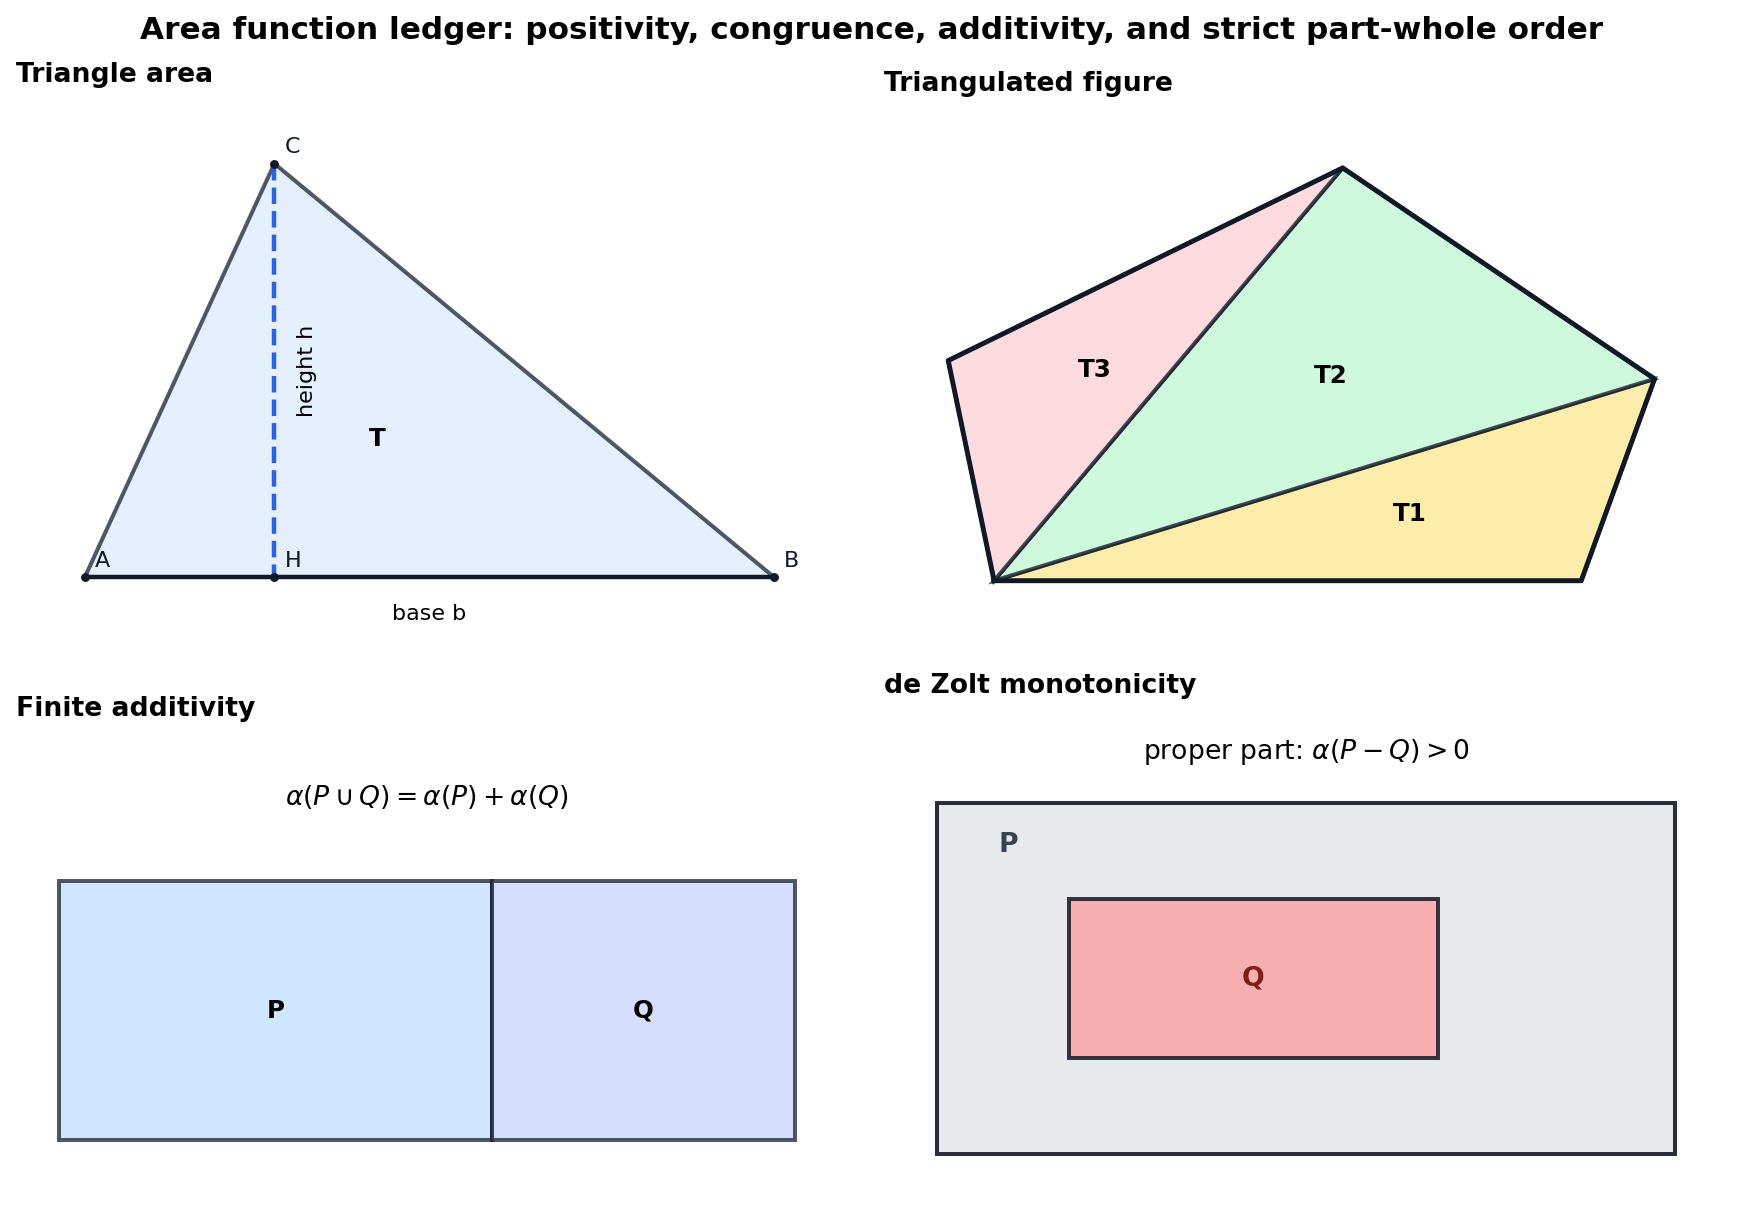

{'source_section': '22-23',
 'triangle_area': 4.8,
 'base_height_area': 4.8,
 'base_height_residual': 0.0,
 'symbolic_base_height_residual': '0',
 'polygon_area': 6.18625,
 'triangulation_area_sum': 6.18625,
 'triangulation_residual': 0.0,
 'finite_additivity_residual': 0.0,
 'de_zolt_gap': 6.510000000000001}

In [4]:
triangle_area_value = polygon_area(triangle)
triangle_base_height_value = 0.5 * np.linalg.norm(triangle[1] - triangle[0]) * (triangle[2, 1] - foot[1])
poly_area = polygon_area(poly)
fan_area = sum(polygon_area(tri) for tri in fan_tris)
additivity_residual = polygon_area(np.array([[0, 0], [3.4, 0], [3.4, 1.2], [0, 1.2]])) - (polygon_area(union_left) + polygon_area(union_right))
de_zolt_gap = polygon_area(whole) - polygon_area(part)

area_measure_checks = {
    "source_section": "22-23",
    "triangle_area": float(triangle_area_value),
    "base_height_area": float(triangle_base_height_value),
    "base_height_residual": float(abs(triangle_area_value - triangle_base_height_value)),
    "symbolic_base_height_residual": str(triangle_symbolic_residual),
    "polygon_area": float(poly_area),
    "triangulation_area_sum": float(fan_area),
    "triangulation_residual": float(abs(poly_area - fan_area)),
    "finite_additivity_residual": float(abs(additivity_residual)),
    "de_zolt_gap": float(de_zolt_gap),
}
CHECKS["area_measure"] = area_measure_checks
area_checks_path = remember(save_json(area_measure_checks, UNIT, "checks", "area-measure-checks.json", root=ARTIFACT_ROOT.parent))

display_artifact(area_figure_path, width=900)
area_measure_checks


The important failure mode is visible in the ledger: additivity alone does not say that a larger-looking figure is larger. The strict part-whole statement needs positivity for nonempty interiors. That is why Section 23's area function is not just a way to compute numbers; it supplies the order-theoretic ingredient missing from a purely formal equal-content relation.


## 2. Dissection And The Bolyai-Gerwien Route

A dissection is stronger than equal area because it asks for an explicit finite inventory of pieces and rigid motions. Section 24 proves a route: triangles can be rearranged into parallelograms, parallelograms into rectangles, and, using Archimedes' axiom, rectangles can be normalized to a common base. The Bolyai-Gerwien theorem then says that in an Archimedean Euclidean plane, equal area and dissection equivalence agree for rectilineal figures.

Inspect the next artifact in two ways. First, follow the colored pieces: the moved triangle is congruent to its destination. Second, follow the graph: it names the proof dependencies instead of hiding them inside a single theorem label.


In [5]:
def rotate_half_turn(points, center):
    return 2 * np.asarray(center) - np.asarray(points)

# Triangle -> parallelogram construction from Section 24.
A = np.array([0.7, 2.4])
B = np.array([0.0, 0.0])
C = np.array([4.2, 0.0])
D = 0.5 * (A + C)
E = 0.5 * (A + B)
F = rotate_half_turn(E, D)
tri_piece = np.array([A, D, E])
tri_piece_moved = np.array([C, D, F])
quad_shared = np.array([B, C, D, E])
target_para = np.array([B, C, F, E])

# Parallelogram -> rectangle construction.
A2 = np.array([0.0, 0.0])
B2 = np.array([3.2, 0.0])
C2 = np.array([4.0, 1.5])
D2 = np.array([0.8, 1.5])
E2 = np.array([0.8, 0.0])
F2 = np.array([4.0, 0.0])
para_piece = np.array([A2, D2, E2])
para_piece_moved = np.array([B2, C2, F2])
para_core = np.array([E2, B2, C2, D2])
source_para = np.array([A2, B2, C2, D2])
target_rect = np.array([E2, F2, C2, D2])


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
ax = axes[0, 0]
add_poly(ax, quad_shared, facecolor="#dbeafe", label="shared")
add_poly(ax, tri_piece, facecolor="#fbbf24", label="move")
ax.plot([E[0], D[0]], [E[1], D[1]], color="#111827", lw=2)
annotate_points(ax, {"A": A, "B": B, "C": C, "D": D, "E": E})
style_geometry_axis(ax, "Triangle cut at midpoints")
ax.set_xlim(-0.3, 4.8)
ax.set_ylim(-0.3, 2.8)

ax = axes[0, 1]
add_poly(ax, quad_shared, facecolor="#dbeafe", label="shared")
add_poly(ax, tri_piece_moved, facecolor="#fbbf24", label="moved")
ax.plot([E[0], D[0], F[0]], [E[1], D[1], F[1]], color="#111827", lw=2)
annotate_points(ax, {"B": B, "C": C, "D": D, "E": E, "F": F})
style_geometry_axis(ax, "Same pieces form a parallelogram")
ax.set_xlim(-0.3, 4.8)
ax.set_ylim(-0.3, 2.8)

ax = axes[1, 0]
add_poly(ax, para_core, facecolor="#bfdbfe", label="core")
add_poly(ax, para_piece, facecolor="#fca5a5", label="cut")
add_poly(ax, target_rect + np.array([0.0, -2.05]), facecolor="#d1fae5", alpha=0.35)
add_poly(ax, para_piece_moved + np.array([0.0, -2.05]), facecolor="#fca5a5")
ax.text(3.73, -1.55, "moved", fontsize=10, ha="center", va="center", color="#7f1d1d")
ax.plot([E2[0], D2[0]], [E2[1], D2[1]], color="#111827", lw=2)
ax.text(2.35, -2.22, "same wedge translated", ha="center", fontsize=10)
style_geometry_axis(ax, "Parallelogram to rectangle")
ax.set_xlim(-0.3, 4.4)
ax.set_ylim(-2.35, 1.8)

ax = axes[1, 1]
G = nx.DiGraph()
route_nodes = ["triangulate\nfigures", "triangles ->\nparallelograms", "parallelograms ->\nrectangles", "normalize\nbase length", "match equal\narea rectangles"]
G.add_nodes_from(route_nodes)
G.add_edges_from(zip(route_nodes[:-1], route_nodes[1:]))
pos = {node: (i, 0.0) for i, node in enumerate(route_nodes)}
nx.draw_networkx_nodes(G, pos, node_color=["#dbeafe", "#fef3c7", "#dcfce7", "#ede9fe", "#fee2e2"], node_size=2200, ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", width=1.8, edge_color="#374151", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8.5, ax=ax)
ax.text(1.5, -0.45, "Archimedes' axiom enters at normalization", ha="center", fontsize=10, color="#7c2d12")
style_geometry_axis(ax, "Bolyai-Gerwien proof route")
ax.set_xlim(-0.7, 4.7)
ax.set_ylim(-0.7, 0.5)

fig.suptitle("Dissection as explicit piece accounting", fontsize=14, weight="bold")
fig.tight_layout()
dissection_figure_path = remember(save_matplotlib(fig, UNIT, "figures", "dissection-bolyai-gerwien-route.png", root=ARTIFACT_ROOT.parent))
plt.close(fig)


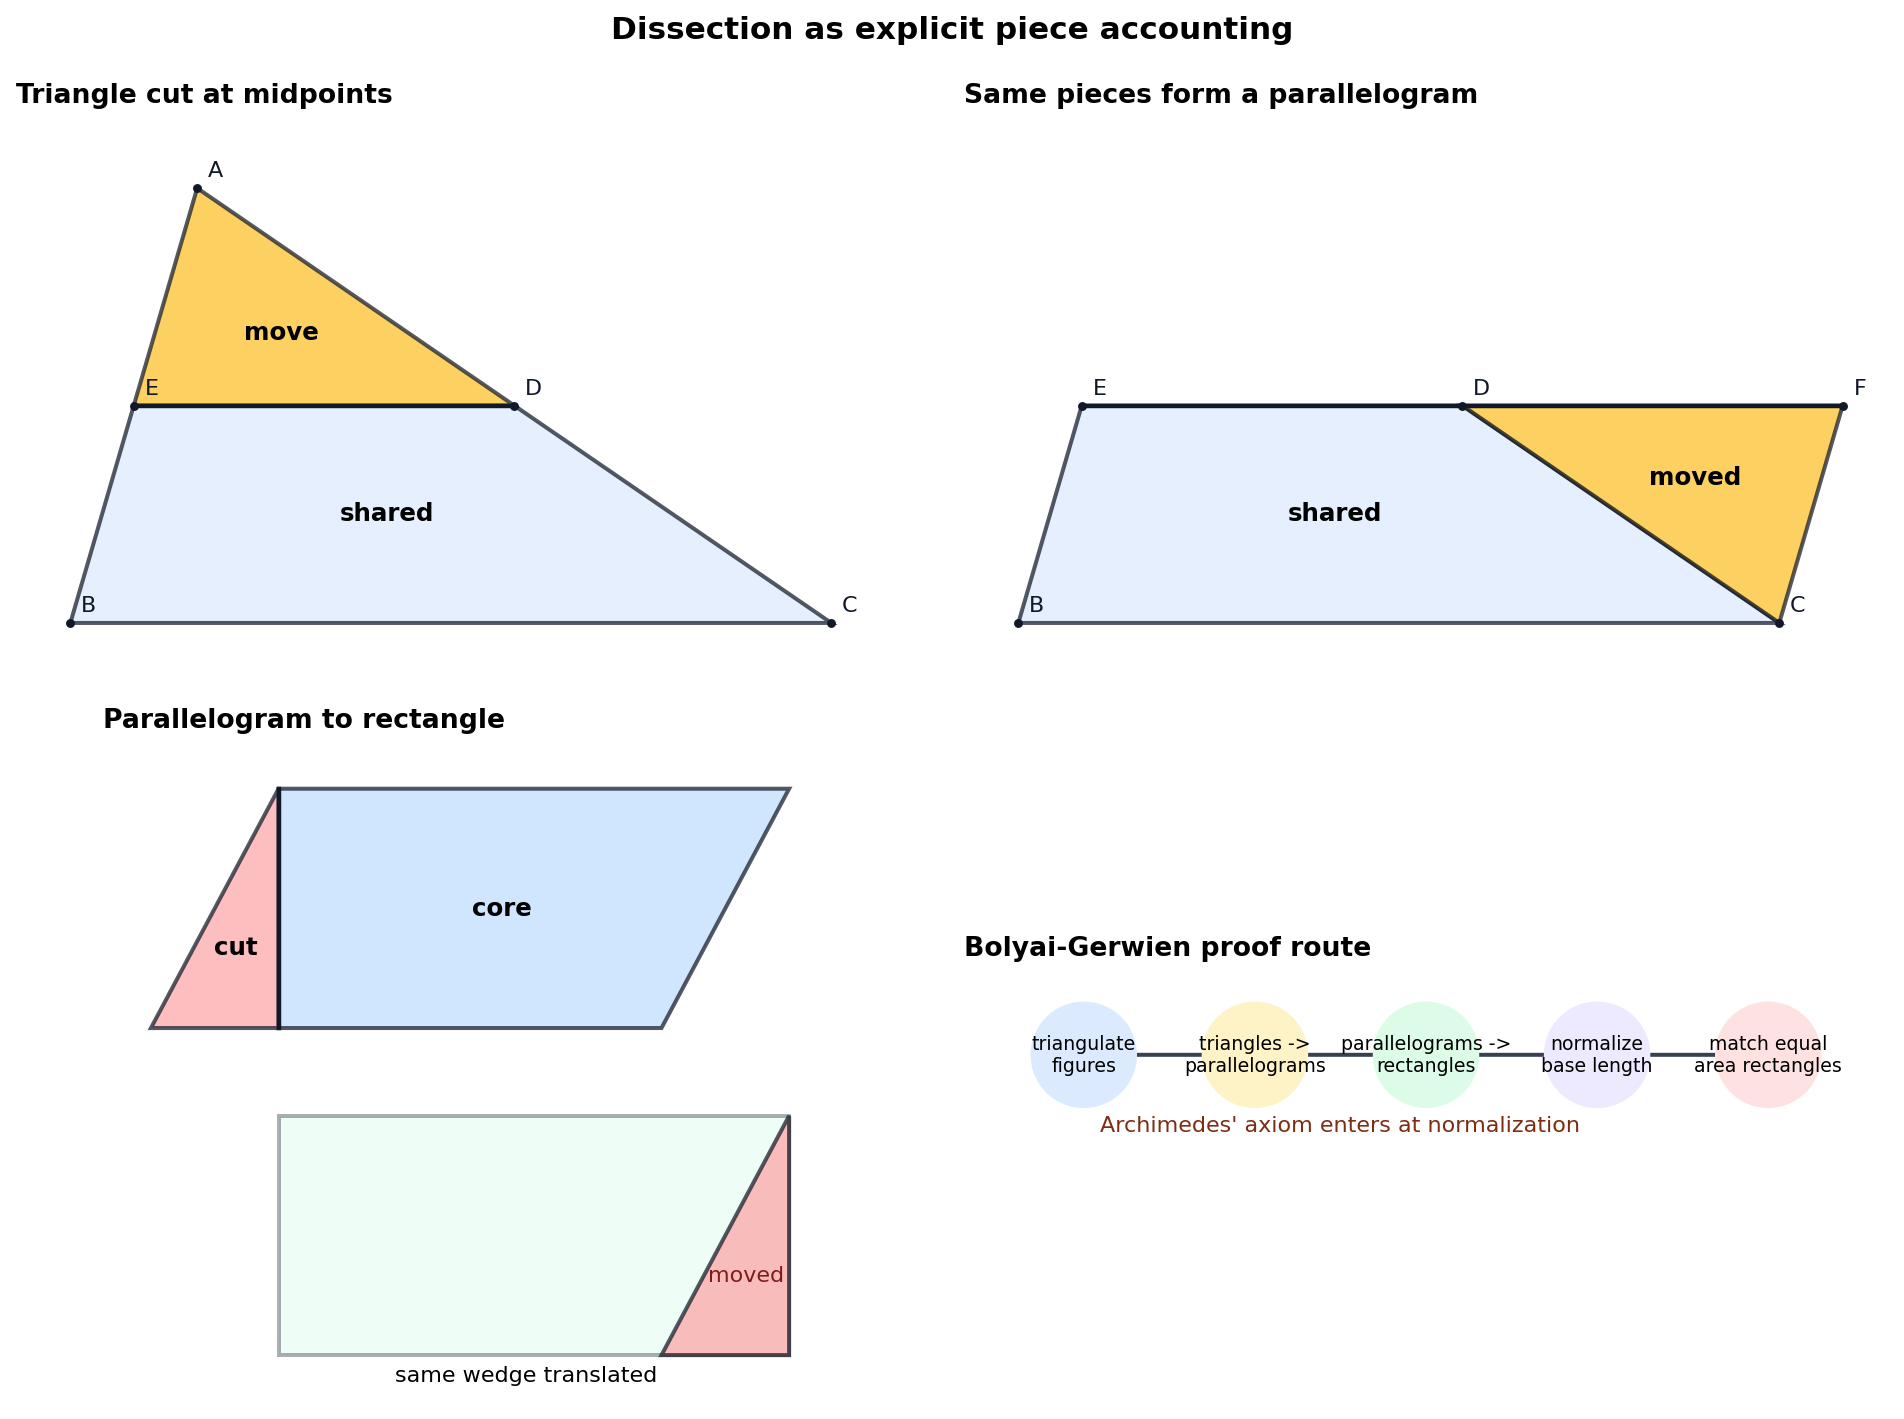

{'source_section': '24',
 'triangle_piece_congruence_residual': 4.440892098500626e-16,
 'triangle_to_parallelogram_area_residual': 0.0,
 'parallelogram_piece_congruence_residual': 2.220446049250313e-16,
 'parallelogram_to_rectangle_area_residual': 8.881784197001252e-16,
 'proof_route_nodes': ['triangulate\nfigures',
  'triangles ->\nparallelograms',
  'parallelograms ->\nrectangles',
  'normalize\nbase length',
  'match equal\narea rectangles'],
 'uses_archimedes_at': 'normalize base length before matching equal-area rectangles'}

In [7]:
triangle_congruence_residual = float(np.max(np.abs(np.sort(side_lengths(tri_piece)) - np.sort(side_lengths(tri_piece_moved)))))
triangle_reassembly_residual = float(abs(polygon_area(np.array([A, B, C])) - polygon_area(target_para)))
parallelogram_congruence_residual = float(np.max(np.abs(np.sort(side_lengths(para_piece)) - np.sort(side_lengths(para_piece_moved)))))
parallelogram_reassembly_residual = float(abs(polygon_area(source_para) - polygon_area(target_rect)))

dissection_checks = {
    "source_section": "24",
    "triangle_piece_congruence_residual": triangle_congruence_residual,
    "triangle_to_parallelogram_area_residual": triangle_reassembly_residual,
    "parallelogram_piece_congruence_residual": parallelogram_congruence_residual,
    "parallelogram_to_rectangle_area_residual": parallelogram_reassembly_residual,
    "proof_route_nodes": route_nodes,
    "uses_archimedes_at": "normalize base length before matching equal-area rectangles",
}
CHECKS["dissection"] = dissection_checks
dissection_checks_path = remember(save_json(dissection_checks, UNIT, "checks", "dissection-checks.json", root=ARTIFACT_ROOT.parent))

display_artifact(dissection_figure_path, width=920)
dissection_checks


The graph also marks a boundary. Without the Archimedean assumption, equal area can fail to give a finite dissection route. That is the role of the non-Archimedean counterexample in Section 22: a parallelogram may have the same content as a unit square while a finite number of bounded triangles cannot reach an infinitely displaced side.


## 3. Circle Quadrature As Exhaustion

Section 25 changes the object class: circles are not rectilineal figures. The chapter treats their area through an exhaustion idea: trap the circle between an inscribed and a circumscribed polygon, then double the number of sides so the gap shrinks below any prescribed tolerance. This is not a ruler-and-compass squaring of the circle; it is a limiting area argument.

The static artifact records three related views: polygon bounds, gap convergence, and the quadratrix curve mentioned in the section. The interactive artifact lets you switch the number of polygon sides and inspect how the annular gap collapses.


In [8]:
def regular_polygon_vertices(n, *, radius=1.0, angle_offset=math.pi / 2):
    theta = angle_offset + np.linspace(0, 2 * math.pi, n, endpoint=False)
    return np.column_stack([radius * np.cos(theta), radius * np.sin(theta)])


def inscribed_area(n, radius=1.0):
    return 0.5 * n * radius**2 * math.sin(2 * math.pi / n)


def circumscribed_area(n, radius=1.0):
    return n * radius**2 * math.tan(math.pi / n)

n_values = [6, 12, 24, 48, 96, 192, 384]
quad_rows = []
for n in n_values:
    inner = inscribed_area(n)
    outer = circumscribed_area(n)
    quad_rows.append({
        "n": n,
        "inscribed_area": inner,
        "circumscribed_area": outer,
        "gap": outer - inner,
        "inner_square_side": math.sqrt(inner),
        "outer_square_side": math.sqrt(outer),
        "pi_error_midpoint": abs((inner + outer) / 2 - math.pi),
    })
quad_df = pd.DataFrame(quad_rows)
quad_df["gap_ratio_after_doubling"] = quad_df["gap"].shift(-1) / quad_df["gap"]
quad_table_path = remember(ARTIFACT_ROOT / "tables" / "circle-quadrature-bounds.csv")
quad_df.to_csv(quad_table_path, index=False)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
ax = axes[0]
n_show = 12
ax.add_patch(Circle((0, 0), 1.0, facecolor="none", edgecolor="#111827", lw=2))
ins = regular_polygon_vertices(n_show, radius=1.0)
out = regular_polygon_vertices(n_show, radius=1 / math.cos(math.pi / n_show), angle_offset=math.pi / 2 + math.pi / n_show)
add_poly(ax, out, facecolor="#fee2e2", edgecolor="#dc2626", alpha=0.35)
add_poly(ax, ins, facecolor="#bfdbfe", edgecolor="#2563eb", alpha=0.45)
ax.text(-1.22, 1.17, "outer polygon", fontsize=10, color="#991b1b", ha="left")
ax.text(-1.22, -1.24, "inner polygon", fontsize=10, color="#1d4ed8", ha="left")
style_geometry_axis(ax, "Polygon area bounds")
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)

ax = axes[1]
ax.plot(quad_df["n"], quad_df["inscribed_area"], marker="o", label="inscribed")
ax.plot(quad_df["n"], quad_df["circumscribed_area"], marker="o", label="circumscribed")
ax.axhline(math.pi, color="#111827", lw=1.5, ls="--", label="pi")
ax.set_xscale("log", base=2)
ax.set_xlabel("number of sides")
ax.set_ylabel("area for unit circle")
ax.set_title("Bounds squeeze circle area", loc="left", fontsize=12, weight="bold")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)

ax = axes[2]
theta = np.linspace(1e-3, math.pi / 2, 500)
x = 2 * theta / (math.pi * np.tan(theta))
y = 2 * theta / math.pi
ax.plot(x, y, color="#7c3aed", lw=2.5)
ax.scatter([2 / math.pi], [0], color="#7c3aed", zorder=3)
ax.text(2 / math.pi + 0.03, 0.04, r"limit $2/\pi$", fontsize=10)
ax.add_patch(Circle((0, 0), 1.0, facecolor="none", edgecolor="#9ca3af", lw=1.5, ls="--"))
ax.set_xlabel("x")
ax.set_ylabel("y")
style_geometry_axis(ax, "Quadratrix sample curve")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.08, 1.05)

fig.suptitle("Quadrature: exhaustion bounds and the lure of auxiliary curves", fontsize=14, weight="bold")
fig.tight_layout()
quadrature_figure_path = remember(save_matplotlib(fig, UNIT, "figures", "circle-quadrature-exhaustion.png", root=ARTIFACT_ROOT.parent))
plt.close(fig)


In [10]:
slider_ns = [6, 12, 24, 48, 96]
t = np.linspace(0, 2 * math.pi, 300)
circle_trace = go.Scatter(x=np.cos(t), y=np.sin(t), mode="lines", name="circle", line=dict(color="#111827", width=2))

def polygon_trace(n, circumscribed=False):
    radius = 1 / math.cos(math.pi / n) if circumscribed else 1.0
    offset = math.pi / 2 + (math.pi / n if circumscribed else 0.0)
    pts = regular_polygon_vertices(n, radius=radius, angle_offset=offset)
    pts = np.vstack([pts, pts[0]])
    return go.Scatter(
        x=pts[:, 0], y=pts[:, 1], mode="lines", fill="toself",
        name=("outer" if circumscribed else "inner"),
        line=dict(color="#dc2626" if circumscribed else "#2563eb", width=2),
        fillcolor="rgba(220,38,38,0.16)" if circumscribed else "rgba(37,99,235,0.20)",
    )

plotly_fig = go.Figure(data=[circle_trace, polygon_trace(slider_ns[0], False), polygon_trace(slider_ns[0], True)])
plotly_fig.frames = [
    go.Frame(
        data=[circle_trace, polygon_trace(n, False), polygon_trace(n, True)],
        name=str(n),
        layout=go.Layout(title_text=f"Inscribed/circumscribed {n}-gons: gap {circumscribed_area(n) - inscribed_area(n):.6f}"),
    )
    for n in slider_ns
]
plotly_fig.update_layout(
    title=f"Inscribed/circumscribed {slider_ns[0]}-gons: gap {circumscribed_area(slider_ns[0]) - inscribed_area(slider_ns[0]):.6f}",
    xaxis=dict(scaleanchor="y", scaleratio=1, range=[-1.35, 1.35], zeroline=False),
    yaxis=dict(range=[-1.35, 1.35], zeroline=False),
    width=760,
    height=560,
    margin=dict(l=20, r=20, t=60, b=20),
    sliders=[dict(active=0, currentvalue={"prefix": "sides: "}, steps=[
        dict(method="animate", args=[[str(n)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}}], label=str(n))
        for n in slider_ns
    ])],
)
quadrature_html_path = remember(save_plotly_html(plotly_fig, UNIT, "interactive", "quadrature-gap-lab.html", root=ARTIFACT_ROOT.parent))


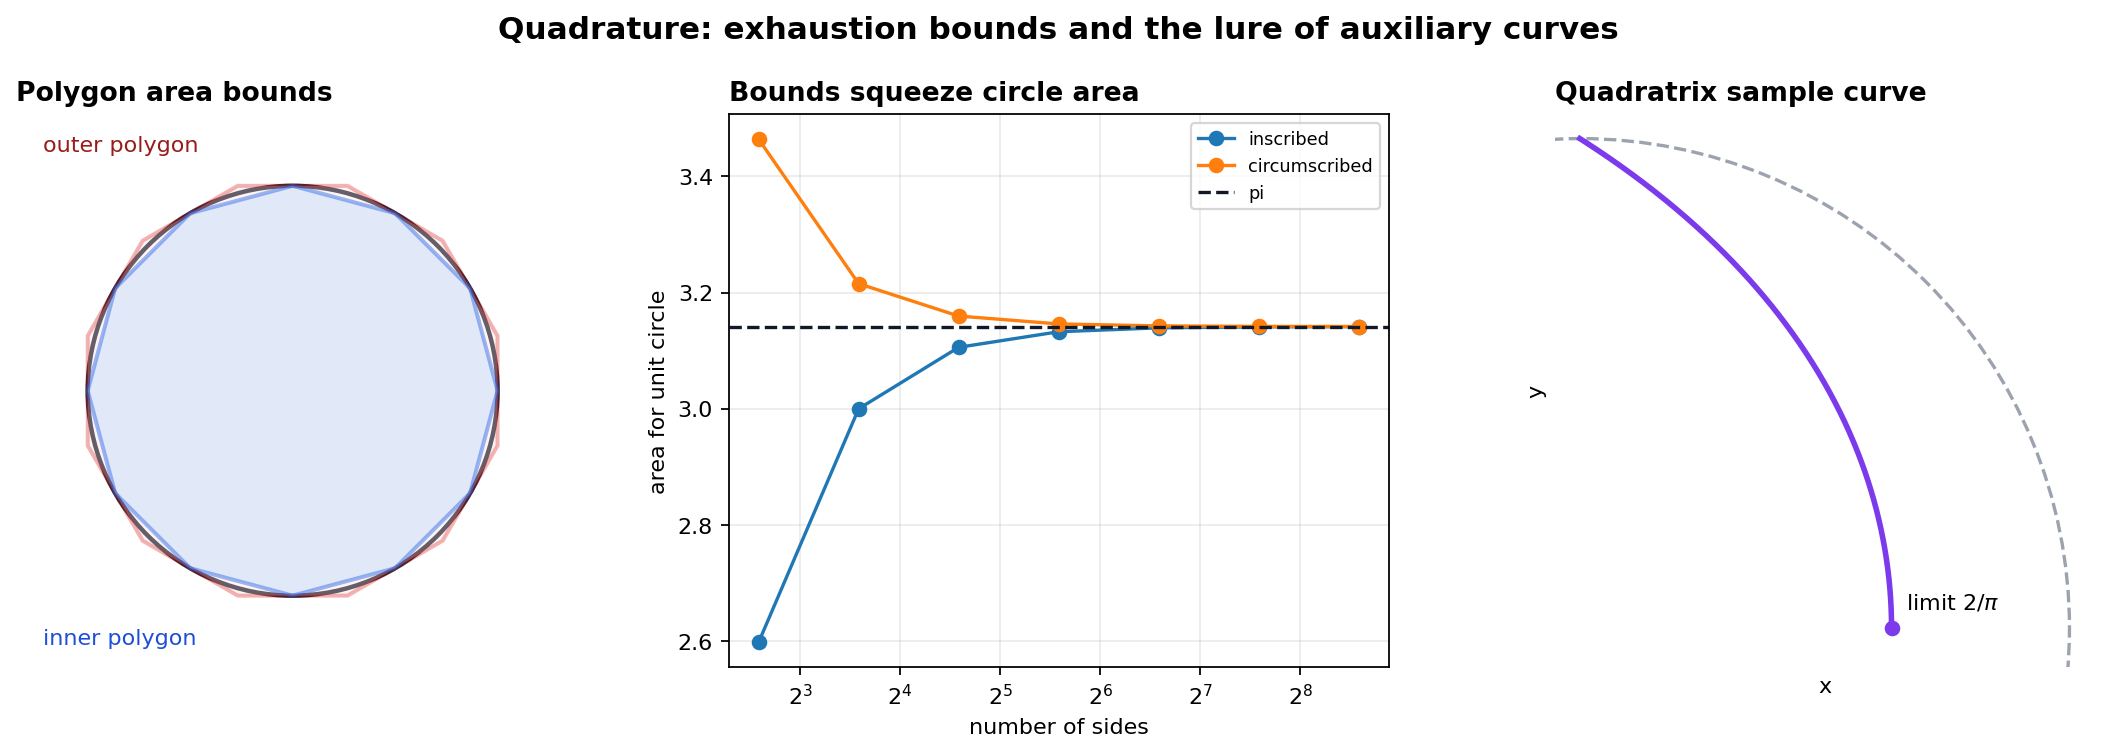

,n,inscribed_area,circumscribed_area,gap,inner_square_side,outer_square_side,pi_error_midpoint,gap_ratio_after_doubling
0,6,2.598076,3.464102,0.866025,1.611855,1.861210,0.110504,0.248711
1,12,3.000000,3.215390,0.215390,1.732051,1.793151,0.033897,0.249925
2,24,3.105829,3.159660,0.053831,1.762336,1.777543,0.008848,0.249995
3,48,3.132629,3.146086,0.013458,1.769923,1.773721,0.002235,0.250000
4,96,3.139350,3.142715,0.003364,1.771821,1.772770,0.000560,0.250000
5,192,3.141032,3.141873,0.000841,1.772296,1.772533,0.000140,0.250000
6,384,3.141452,3.141663,0.000210,1.772414,1.772474,0.000035,NaN


In [11]:
archimedes_lower = 223 / 71
archimedes_upper = 22 / 7
gap_ratios = quad_df["gap_ratio_after_doubling"].dropna().to_numpy()
quadrature_checks = {
    "source_section": "25",
    "n_values": n_values,
    "pi_bracketed_by_all_polygon_bounds": bool(((quad_df["inscribed_area"] <= math.pi) & (math.pi <= quad_df["circumscribed_area"])).all()),
    "max_gap_ratio_after_doubling": float(np.max(gap_ratios)),
    "gap_halves_under_doubling": bool(np.max(gap_ratios) < 0.5),
    "last_gap": float(quad_df.iloc[-1]["gap"]),
    "archimedes_lower_223_over_71": float(archimedes_lower),
    "archimedes_upper_22_over_7": float(archimedes_upper),
    "archimedes_bracket_contains_pi": bool(archimedes_lower < math.pi < archimedes_upper),
    "quadratrix_limit_x": float(2 / math.pi),
}
CHECKS["quadrature"] = quadrature_checks
quadrature_checks_path = remember(save_json(quadrature_checks, UNIT, "checks", "circle-quadrature-checks.json", root=ARTIFACT_ROOT.parent))

display_artifact(quadrature_figure_path, width=980)
display_artifact(quadrature_html_path, width="100%", height=590)
quad_df


The exhaustion table is the computational analogue of the chapter's proposition: each doubling makes the undecided annular area smaller. The quadratrix panel is included for a different reason. It shows why extra tools can make a forbidden classical construction look easy: once the limiting curve is admitted, the coordinate `2/pi` is visible, but the construction is no longer the ruler-and-compass problem.


## 4. Volume And Hilbert's Third Problem

Section 26 explains why Euclid's volume arguments need exhaustion for pyramids. Section 27 then answers Hilbert's third problem: volume alone is not a complete scissors invariant in 3D. The Dehn invariant adds an angle ledger to the volume ledger. Cubes have only right dihedral angles, which vanish in the quotient by multiples of `pi`; a regular tetrahedron has dihedral angle `acos(1/3)`, and that angle is not a rational multiple of `pi`.

The interactive scene below deliberately scales the cube to have the same volume as the regular tetrahedron. Rotate it and inspect the edge structure: equal volume is visible, but the edge-angle ledger is different.


In [12]:
tetra_vertices = np.array([
    [0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [0.5, math.sqrt(3) / 2, 0.0],
    [0.5, math.sqrt(3) / 6, math.sqrt(2 / 3)],
])
tetra_faces = np.array([[0, 1, 2], [0, 3, 1], [1, 3, 2], [2, 3, 0]])

def tetra_volume(vertices):
    v0, v1, v2, v3 = vertices
    return abs(np.linalg.det(np.vstack([v1 - v0, v2 - v0, v3 - v0]))) / 6


def mesh_edges(faces):
    edges = set()
    for face in faces:
        for i in range(3):
            a, b = sorted((int(face[i]), int(face[(i + 1) % 3])))
            edges.add((a, b))
    return sorted(edges)


def edge_trace(vertices, edges, *, name, color="#111827"):
    xs, ys, zs = [], [], []
    for a, b in edges:
        for idx in (a, b):
            xs.append(vertices[idx, 0]); ys.append(vertices[idx, 1]); zs.append(vertices[idx, 2])
        xs.append(None); ys.append(None); zs.append(None)
    return go.Scatter3d(x=xs, y=ys, z=zs, mode="lines", line=dict(color=color, width=4), name=name, showlegend=False)

tetra_vol = tetra_volume(tetra_vertices)
cube_side = tetra_vol ** (1 / 3)
cube_vertices = np.array([
    [0, 0, 0], [cube_side, 0, 0], [cube_side, cube_side, 0], [0, cube_side, 0],
    [0, 0, cube_side], [cube_side, 0, cube_side], [cube_side, cube_side, cube_side], [0, cube_side, cube_side],
])
cube_faces = np.array([
    [0, 1, 2], [0, 2, 3], [4, 6, 5], [4, 7, 6], [0, 4, 5], [0, 5, 1],
    [1, 5, 6], [1, 6, 2], [2, 6, 7], [2, 7, 3], [3, 7, 4], [3, 4, 0],
])
cube_edges = sorted({tuple(sorted(edge)) for face in cube_faces for edge in [(face[0], face[1]), (face[1], face[2]), (face[2], face[0])]})
tetra_edges = mesh_edges(tetra_faces)


In [13]:
volume_fig = make_subplots(
    rows=1, cols=2, specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("regular tetrahedron, edge 1", "cube scaled to the same volume"),
)
volume_fig.add_trace(go.Mesh3d(
    x=tetra_vertices[:, 0], y=tetra_vertices[:, 1], z=tetra_vertices[:, 2],
    i=tetra_faces[:, 0], j=tetra_faces[:, 1], k=tetra_faces[:, 2],
    color="#f59e0b", opacity=0.62, name="tetrahedron", showlegend=False,
), row=1, col=1)
volume_fig.add_trace(edge_trace(tetra_vertices, tetra_edges, name="tetra edges", color="#92400e"), row=1, col=1)
volume_fig.add_trace(go.Mesh3d(
    x=cube_vertices[:, 0], y=cube_vertices[:, 1], z=cube_vertices[:, 2],
    i=cube_faces[:, 0], j=cube_faces[:, 1], k=cube_faces[:, 2],
    color="#60a5fa", opacity=0.5, name="cube", showlegend=False,
), row=1, col=2)
volume_fig.add_trace(edge_trace(cube_vertices, cube_edges, name="cube edges", color="#1d4ed8"), row=1, col=2)
volume_fig.update_layout(
    title="Equal volume is not enough: Dehn's edge-angle ledger separates these solids",
    height=620,
    margin=dict(l=0, r=0, t=70, b=0),
    scene=dict(aspectmode="data"),
    scene2=dict(aspectmode="data"),
)
volume_html_path = remember(save_plotly_html(volume_fig, UNIT, "interactive", "volume-dehn-obstruction.html", root=ARTIFACT_ROOT.parent))


In [14]:
mesh_tetra_volume = mesh_cube_volume = mesh_tetra_euler = mesh_cube_euler = None
if trimesh is not None:
    tet_mesh = trimesh.Trimesh(vertices=tetra_vertices, faces=tetra_faces, process=False)
    cube_mesh = trimesh.Trimesh(vertices=cube_vertices, faces=cube_faces, process=False)
    mesh_tetra_volume = float(abs(tet_mesh.volume))
    mesh_cube_volume = float(abs(cube_mesh.volume))
    mesh_tetra_euler = int(tet_mesh.euler_number)
    mesh_cube_euler = int(cube_mesh.euler_number)

alpha = sp.acos(sp.Rational(1, 3))
z = sp.symbols("z")
tetra_angle_polynomial = sp.Poly(3 * z**2 - 2 * z + 3, z)
degree_two_cyclotomics = [sp.Poly(sp.cyclotomic_poly(q, z), z) for q in range(1, 13) if sp.totient(q) <= 2]
tetra_poly_matches_degree_two_cyclotomic = any(sp.monic(poly.as_expr()) == sp.monic(tetra_angle_polynomial.as_expr()) for poly in degree_two_cyclotomics)
rational_angle_hits = []
alpha_over_pi = float(sp.N(alpha / sp.pi, 30))
for q in range(1, 129):
    for p in range(1, q):
        if math.gcd(p, q) == 1 and abs(alpha_over_pi - p / q) < 1e-12:
            rational_angle_hits.append((p, q))

volume_dehn_checks = {
    "source_sections": "26-27",
    "tetrahedron_edge_length": 1.0,
    "tetrahedron_volume_formula": float(tetra_vol),
    "cube_side_for_equal_volume": float(cube_side),
    "cube_volume": float(cube_side**3),
    "volume_residual": float(abs(cube_side**3 - tetra_vol)),
    "trimesh_available": bool(trimesh is not None),
    "trimesh_tetra_volume": mesh_tetra_volume,
    "trimesh_cube_volume": mesh_cube_volume,
    "trimesh_tetra_euler": mesh_tetra_euler,
    "trimesh_cube_euler": mesh_cube_euler,
    "cube_dehn_ledger": "12(s, pi/2) = 6(s, pi) = 0 in R tensor R/(pi Z)",
    "tetra_dehn_ledger": "6(1, arccos(1/3))",
    "tetra_dihedral_angle_radians": float(sp.N(alpha, 18)),
    "tetra_dihedral_angle_over_pi": alpha_over_pi,
    "tetra_angle_polynomial": str(tetra_angle_polynomial.as_expr()),
    "degree_two_cyclotomic_match": bool(tetra_poly_matches_degree_two_cyclotomic),
    "rational_hits_denominator_le_128": rational_angle_hits,
    "dehn_obstruction_certificate": "cube ledger is zero; tetra ledger is nonzero because arccos(1/3) is not a rational multiple of pi",
}
CHECKS["volume_dehn"] = volume_dehn_checks
volume_checks_path = remember(save_json(volume_dehn_checks, UNIT, "checks", "volume-dehn-checks.json", root=ARTIFACT_ROOT.parent))

display_artifact(volume_html_path, width="100%", height=640)
volume_dehn_checks


{'source_sections': '26-27',
 'tetrahedron_edge_length': 1.0,
 'tetrahedron_volume_formula': 0.1178511301977579,
 'cube_side_for_equal_volume': 0.49028045890548,
 'cube_volume': 0.11785113019775792,
 'volume_residual': 1.3877787807814457e-17,
 'trimesh_available': True,
 'trimesh_tetra_volume': 0.1178511301977579,
 'trimesh_cube_volume': 0.1178511301977579,
 'trimesh_tetra_euler': 2,
 'trimesh_cube_euler': 2,
 'cube_dehn_ledger': '12(s, pi/2) = 6(s, pi) = 0 in R tensor R/(pi Z)',
 'tetra_dehn_ledger': '6(1, arccos(1/3))',
 'tetra_dihedral_angle_radians': 1.2309594173407747,
 'tetra_dihedral_angle_over_pi': 0.3918265520306073,
 'tetra_angle_polynomial': '3*z**2 - 2*z + 3',
 'degree_two_cyclotomic_match': False,
 'rational_hits_denominator_le_128': [],
 'dehn_obstruction_certificate': 'cube ledger is zero; tetra ledger is nonzero because arccos(1/3) is not a rational multiple of pi'}

The point is not that the tetrahedron has a mysterious volume. Its volume was deliberately matched to the cube. The obstruction is angular: dissection can cut edges into pieces and glue angles, but the Dehn ledger is designed so those operations preserve the total class. This is the three-dimensional analogue of an invariant proof: to prove impossibility, compute something preserved by all allowed moves and show the two targets differ.


## Applied Lab: When Does A One-Cut Shear Dissection Work?

The rectangle and parallelogram constructions in Section 24 are effective but conditional. In the simple one-cut parallelogram-to-rectangle move, the altitude foot should land on the base segment. When it does not, the proof changes roles or uses the Archimedean scaling step from the rectangle normalization argument.

Edit the `shear_values` list and rerun the cell. The invariant to watch is the determinant area: it is constant for every shear. The construction status column records whether the most direct one-cut picture applies without any preliminary normalization.


In [15]:
base = 3.0
height = 1.2
shear_values = [-1.4, 0.0, 0.45, 1.4, 2.9, 3.7, 5.2]
lab_rows = []
for shear in shear_values:
    parallelogram = np.array([[0.0, 0.0], [base, 0.0], [base + shear, height], [shear, height]])
    determinant_area = abs(np.linalg.det(np.array([[base, 0.0], [shear, height]])))
    foot_inside = 0 <= shear <= base
    wedge_area = 0.5 * abs(shear) * height
    lab_rows.append({
        "base": base,
        "height": height,
        "shear": shear,
        "determinant_area": determinant_area,
        "shoelace_area": polygon_area(parallelogram),
        "one_cut_foot_inside_base": foot_inside,
        "simple_wedge_area": wedge_area,
        "area_residual": abs(determinant_area - polygon_area(parallelogram)),
    })
lab_df = pd.DataFrame(lab_rows)
lab_table_path = remember(ARTIFACT_ROOT / "tables" / "applied-dissection-shear-lab.csv")
lab_df.to_csv(lab_table_path, index=False)


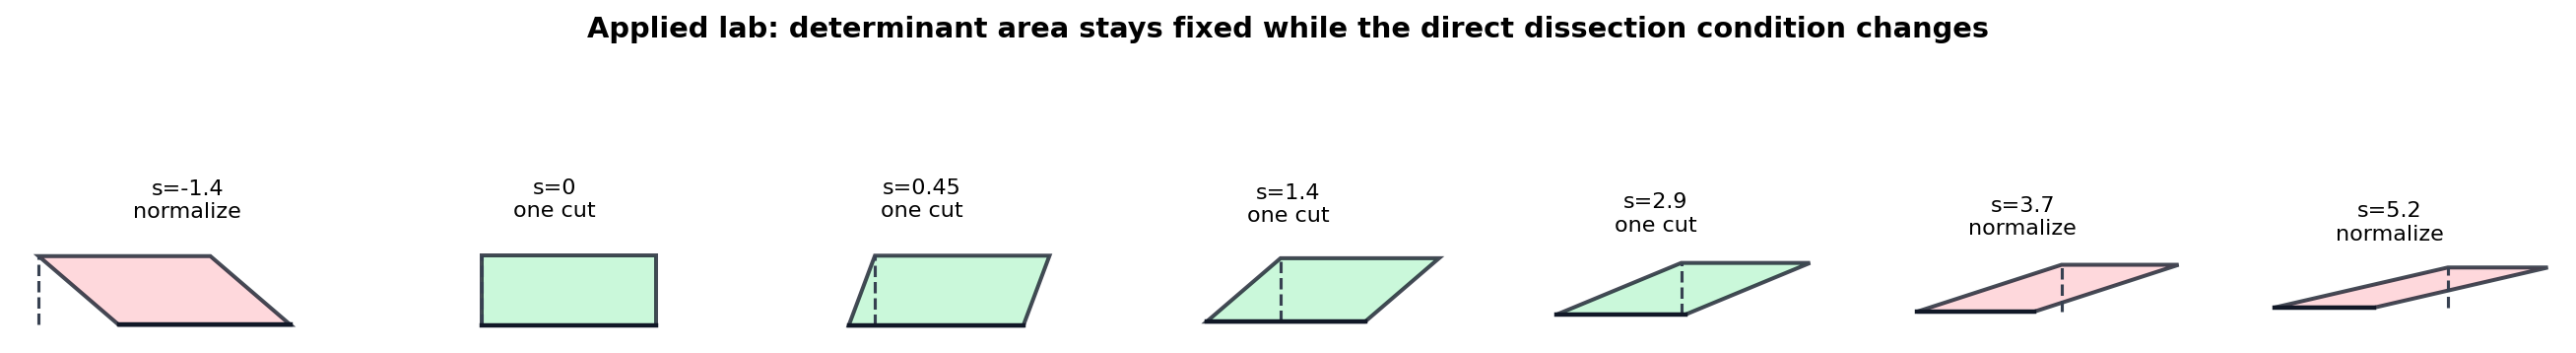

,base,height,shear,determinant_area,shoelace_area,one_cut_foot_inside_base,simple_wedge_area,area_residual
0,3.0,1.2,-1.40,3.6,3.6,False,0.84,8.881784e-16
1,3.0,1.2,0.00,3.6,3.6,True,0.00,8.881784e-16
2,3.0,1.2,0.45,3.6,3.6,True,0.27,8.881784e-16
3,3.0,1.2,1.40,3.6,3.6,True,0.84,8.881784e-16
4,3.0,1.2,2.90,3.6,3.6,True,1.74,8.881784e-16
5,3.0,1.2,3.70,3.6,3.6,False,2.22,4.440892e-16
6,3.0,1.2,5.20,3.6,3.6,False,3.12,0.000000e+00


In [16]:
fig, axes = plt.subplots(1, len(shear_values), figsize=(2.35 * len(shear_values), 3.2), sharey=True)
for ax, shear in zip(axes, shear_values):
    pts = np.array([[0.0, 0.0], [base, 0.0], [base + shear, height], [shear, height]])
    foot_inside = 0 <= shear <= base
    add_poly(ax, pts, facecolor="#bbf7d0" if foot_inside else "#fecdd3", edgecolor="#111827", alpha=0.78)
    ax.plot([shear, shear], [0, height], color="#374151", lw=1.4, ls="--")
    ax.plot([0, base], [0, 0], color="#111827", lw=2)
    ax.set_title(f"s={shear:g}\n" + ("one cut" if foot_inside else "normalize"), fontsize=10)
    style_geometry_axis(ax)
    ax.set_xlim(min(-1.7, shear - 0.4), max(base + 1.2, base + shear + 0.4))
    ax.set_ylim(-0.2, height + 0.45)
fig.suptitle("Applied lab: determinant area stays fixed while the direct dissection condition changes", fontsize=13, weight="bold")
fig.tight_layout()
lab_figure_path = remember(save_matplotlib(fig, UNIT, "figures", "applied-dissection-shear-lab.png", root=ARTIFACT_ROOT.parent))
plt.close(fig)

applied_lab_checks = {
    "source_section": "24",
    "rows": int(len(lab_df)),
    "max_area_residual": float(lab_df["area_residual"].max()),
    "all_determinant_areas_equal": bool(np.allclose(lab_df["determinant_area"], base * height)),
    "one_cut_cases": int(lab_df["one_cut_foot_inside_base"].sum()),
    "normalization_needed_cases": int((~lab_df["one_cut_foot_inside_base"]).sum()),
}
CHECKS["applied_lab"] = applied_lab_checks
applied_lab_checks_path = remember(save_json(applied_lab_checks, UNIT, "checks", "applied-lab-checks.json", root=ARTIFACT_ROOT.parent))

display_artifact(lab_figure_path, width=980)
lab_df


## final_sanity

The final cell checks the chapter's computational spine rather than just confirming that files were written. It verifies area additivity, dissection congruence residuals, quadrature bracketing, the volume match, the Dehn-angle certificate, generated artifact sizes, and that the notebook no longer contains the generic visual-builder call from the earlier stub.


In [17]:
artifact_paths = sorted(set(ARTIFACTS))
for rel in artifact_paths:
    assert_artifact(BOOK_ROOT / rel, min_bytes=64)

assert CHECKS["area_measure"]["symbolic_base_height_residual"] == "0"
assert CHECKS["area_measure"]["base_height_residual"] < 1e-12
assert CHECKS["area_measure"]["triangulation_residual"] < 1e-12
assert CHECKS["area_measure"]["finite_additivity_residual"] < 1e-12
assert CHECKS["area_measure"]["de_zolt_gap"] > 0

assert CHECKS["dissection"]["triangle_piece_congruence_residual"] < 1e-12
assert CHECKS["dissection"]["triangle_to_parallelogram_area_residual"] < 1e-12
assert CHECKS["dissection"]["parallelogram_piece_congruence_residual"] < 1e-12
assert CHECKS["dissection"]["parallelogram_to_rectangle_area_residual"] < 1e-12

assert CHECKS["quadrature"]["pi_bracketed_by_all_polygon_bounds"]
assert CHECKS["quadrature"]["gap_halves_under_doubling"]
assert CHECKS["quadrature"]["archimedes_bracket_contains_pi"]

assert CHECKS["volume_dehn"]["volume_residual"] < 1e-12
assert not CHECKS["volume_dehn"]["degree_two_cyclotomic_match"]
assert CHECKS["volume_dehn"]["rational_hits_denominator_le_128"] == []

assert CHECKS["applied_lab"]["max_area_residual"] < 1e-12
assert CHECKS["applied_lab"]["all_determinant_areas_equal"]

notebook_source = (CHAPTER_ROOT / "05-area.ipynb").read_text(encoding="utf-8")
forbidden = "build" + "_unit" + "_visuals"
assert forbidden not in notebook_source

visual_summary = {
    "unit": UNIT,
    "source_span": "printed pp. 195-240 / PDF pp. 207-252; Sections 22-27",
    "artifact_count_before_final_reports": len(artifact_paths),
    "artifacts": artifact_paths,
    "checks": CHECKS,
    "generic_visual_builder_absent": True,
}
visual_checks_path = remember(save_json(visual_summary, UNIT, "checks", "visual-checks.json", root=ARTIFACT_ROOT.parent))

final_sanity = {
    "unit": UNIT,
    "source_span": visual_summary["source_span"],
    "artifact_count": len(sorted(set(ARTIFACTS))),
    "artifact_names": [Path(p).name for p in sorted(set(ARTIFACTS))],
    "area_core_residuals": {
        "base_height": CHECKS["area_measure"]["base_height_residual"],
        "triangulation": CHECKS["area_measure"]["triangulation_residual"],
        "additivity": CHECKS["area_measure"]["finite_additivity_residual"],
    },
    "dissection_core_residuals": {
        "triangle_piece_congruence": CHECKS["dissection"]["triangle_piece_congruence_residual"],
        "triangle_reassembly": CHECKS["dissection"]["triangle_to_parallelogram_area_residual"],
        "parallelogram_piece_congruence": CHECKS["dissection"]["parallelogram_piece_congruence_residual"],
        "parallelogram_reassembly": CHECKS["dissection"]["parallelogram_to_rectangle_area_residual"],
    },
    "quadrature_last_gap": CHECKS["quadrature"]["last_gap"],
    "volume_residual": CHECKS["volume_dehn"]["volume_residual"],
    "dehn_certificate": CHECKS["volume_dehn"]["dehn_obstruction_certificate"],
    "generic_visual_builder_absent": True,
}
final_sanity_path = remember(save_json(final_sanity, UNIT, "checks", "final-sanity.json", root=ARTIFACT_ROOT.parent))
notebook_sanity_path = remember(save_json(final_sanity, UNIT, "checks", "notebook-sanity.json", root=ARTIFACT_ROOT.parent))

for rel in sorted(set(ARTIFACTS)):
    assert_artifact(BOOK_ROOT / rel, min_bytes=64)

print(json.dumps(final_sanity, indent=2))


{
  "unit": "chapter-05",
  "source_span": "printed pp. 195-240 / PDF pp. 207-252; Sections 22-27",
  "artifact_count": 14,
  "artifact_names": [
    "applied-lab-checks.json",
    "area-measure-checks.json",
    "circle-quadrature-checks.json",
    "dissection-checks.json",
    "visual-checks.json",
    "volume-dehn-checks.json",
    "applied-dissection-shear-lab.png",
    "area-measure-function-ledger.png",
    "circle-quadrature-exhaustion.png",
    "dissection-bolyai-gerwien-route.png",
    "quadrature-gap-lab.html",
    "volume-dehn-obstruction.html",
    "applied-dissection-shear-lab.csv",
    "circle-quadrature-bounds.csv"
  ],
  "area_core_residuals": {
    "base_height": 0.0,
    "triangulation": 0.0,
    "additivity": 0.0
  },
  "dissection_core_residuals": {
    "triangle_piece_congruence": 4.440892098500626e-16,
    "triangle_reassembly": 0.0,
    "parallelogram_piece_congruence": 2.220446049250313e-16,
    "parallelogram_reassembly": 8.881784197001252e-16
  },
  "quadratur

## Takeaways

- Equal content is a synthetic equivalence relation built from finite triangle decompositions and auxiliary congruent pieces.
- A measure of area function turns content into an ordered additive invariant; its positivity supplies the part-whole principle.
- In an Archimedean Euclidean plane, Bolyai-Gerwien makes equal area equivalent to finite dissection for rectilineal figures.
- Circle quadrature is naturally an exhaustion problem: polygonal bounds squeeze the area, but exact ruler-and-compass squaring fails because `pi` is transcendental.
- Volume behaves like area for many prism and pyramid comparisons only after a limiting argument.
- Hilbert's third problem shows that 3D scissors equivalence needs more than volume; the Dehn invariant detects a regular tetrahedron where volume cannot.
